In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import requests
from io import StringIO
import os
from datetime import datetime, timedelta
import logging
from IPython.display import Markdown

In [4]:
# Load CSV file
stock_data = pd.read_csv('stock_data.csv')

# Show the first few rows
print(stock_data.head())

# Show all column names
print(stock_data.columns.tolist())

         Date    A.close     A.open  AAPL.close  AAPL.open  ABBV.close  \
0  22/03/2010  21.563597  21.269431    6.763536   6.634736         NaN   
1  23/03/2010  21.813002  21.601970    6.872173   6.790318         NaN   
2  24/03/2010  21.678694  21.729854    6.902567   6.850505         NaN   
3  25/03/2010  22.094370  21.806600    6.820715   6.949215         NaN   
4  26/03/2010  21.940891  22.158317    6.948610   6.889927         NaN   

   ABBV.open  ABNB.close  ABNB.open  ABT.close  ...  XYL.close  XYL.open  \
0        NaN         NaN        NaN  18.598389  ...        NaN       NaN   
1        NaN         NaN        NaN  18.760651  ...        NaN       NaN   
2        NaN         NaN        NaN  18.598389  ...        NaN       NaN   
3        NaN         NaN        NaN  18.477552  ...        NaN       NaN   
4        NaN         NaN        NaN  18.263506  ...        NaN       NaN   

   YUM.close   YUM.open  ZBH.close   ZBH.open  ZBRA.close  ZBRA.open  \
0  20.547918  20.354020  5

In [6]:
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

In [7]:
# Min and max dates in the cleaned DataFrame
min_date = stock_data['Date'].min()
max_date = stock_data['Date'].max()

print(f"Min Date: {min_date}")
print(f"Max Date: {max_date}")

Min Date: 2010-03-22 00:00:00
Max Date: 2025-03-14 00:00:00


In [8]:

# Make sure pandas doesn't truncate output
pd.set_option('display.max_rows', None)

# Count NaN values in each column
nan_counts = stock_data.isna().sum()

# Sort from most to least NaNs
nan_counts_sorted = nan_counts.sort_values(ascending=False)

# Print all 1007 columns with NaN counts
print(nan_counts_sorted)


ETR.close      3770
CTAS.open      3770
CTAS.close     3770
ETR.open       3770
SW.close       3597
SW.open        3597
SOLV.open      3530
GEV.close      3530
GEV.open       3530
SOLV.close     3530
VLTO.open      3408
VLTO.close     3408
KVUE.close     3303
KVUE.open      3303
GEHC.close     3208
GEHC.open      3208
CEG.open       2979
CEG.close      2979
ABNB.open      2701
ABNB.close     2701
PLTR.open      2651
PLTR.close     2651
CARR.close     2516
CARR.open      2516
OTIS.close     2516
OTIS.open      2516
CRWD.open      2322
CRWD.close     2322
CTVA.open      2310
CTVA.close     2310
UBER.close     2300
UBER.open      2300
DOW.open       2264
DOW.close      2264
FOX.close      2259
FOX.open       2259
FOXA.close     2258
FOXA.open      2258
MRNA.close     2195
MRNA.open      2195
DAY.close      2039
DAY.open       2039
VICI.close     1960
VICI.open      1960
IR.open        1799
IR.close       1799
INVH.open      1729
INVH.close     1729
LW.close       1674
LW.open        1674


In [9]:
# Count how many columns have at least one NaN
num_columns_with_nan = (stock_data.isna().sum() > 0).sum()

print(f"Number of columns with missing data: {num_columns_with_nan}")


Number of columns with missing data: 144


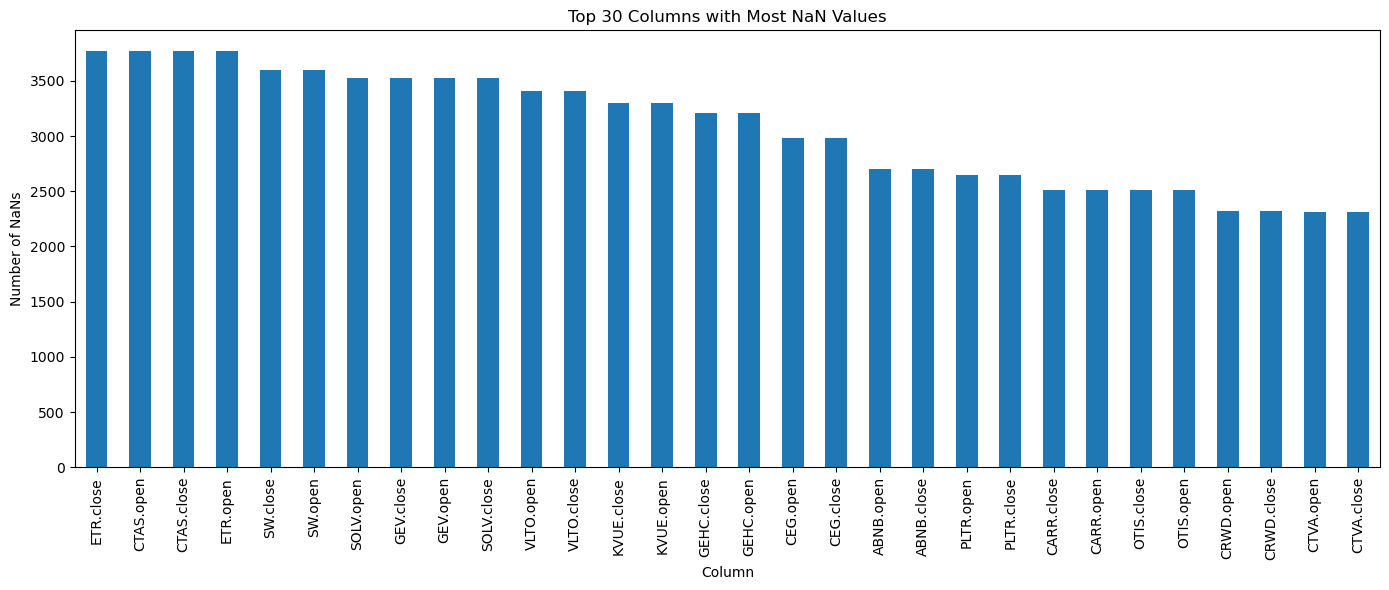

In [11]:
import matplotlib.pyplot as plt

# Plot top 30 columns with most NaNs
nan_counts_sorted.head(30).plot(kind='bar', figsize=(14, 6))
plt.title("Top 30 Columns with Most NaN Values")
plt.ylabel("Number of NaNs")
plt.xlabel("Column")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


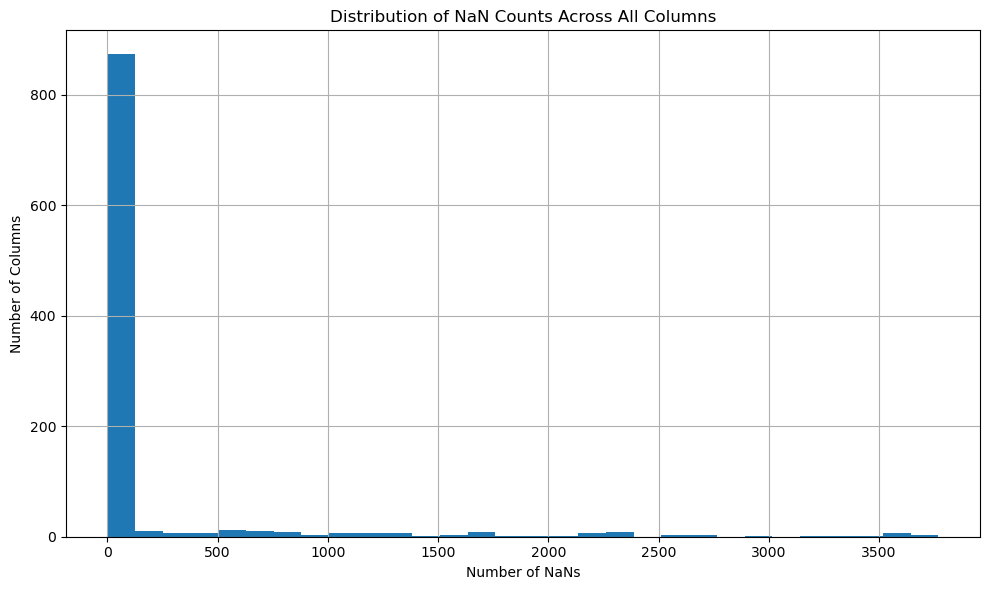

In [8]:
# Histogram showing distribution of NaN counts
plt.figure(figsize=(10, 6))
plt.hist(nan_counts_sorted, bins=30)
plt.title("Distribution of NaN Counts Across All Columns")
plt.xlabel("Number of NaNs")
plt.ylabel("Number of Columns")
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
# Missing values per Date

# Count NaNs per row (per date)
nan_per_date = stock_data.isna().sum(axis=1)

# Optionally, you can attach this to the date column
nan_by_date = pd.DataFrame({
    'Date': stock_data['Date'],
    'MissingCount': nan_per_date
})

print(nan_by_date)


           Date  MissingCount
0    2010-03-22           144
1    2010-03-23           144
2    2010-03-24           144
3    2010-03-25           144
4    2010-03-26           144
5    2010-03-29           144
6    2010-03-30           144
7    2010-03-31           144
8    2010-04-01           144
9    2010-04-05           144
10   2010-04-06           144
11   2010-04-07           144
12   2010-04-08           144
13   2010-04-09           144
14   2010-04-12           144
15   2010-04-13           144
16   2010-04-14           144
17   2010-04-15           144
18   2010-04-16           144
19   2010-04-19           144
20   2010-04-20           144
21   2010-04-21           144
22   2010-04-22           144
23   2010-04-23           144
24   2010-04-26           144
25   2010-04-27           144
26   2010-04-28           142
27   2010-04-29           142
28   2010-04-30           142
29   2010-05-03           142
30   2010-05-04           142
31   2010-05-05           142
32   2010-

In [11]:
# Visualize Missing Data Across Dates

# Convert Date column to datetime if it's not already
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

# Recalculate missing per date (if needed)
nan_by_date = pd.DataFrame({
    'Date': stock_data['Date'],
    'MissingCount': stock_data.isna().sum(axis=1)
})



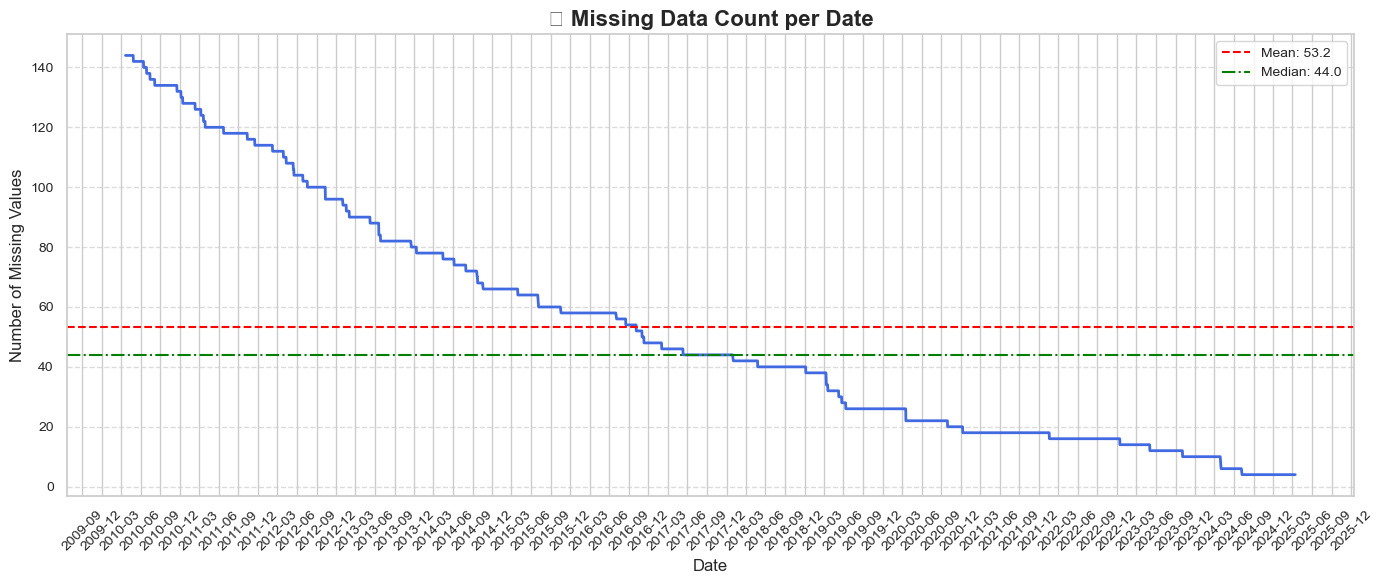

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

# Seaborn style
sns.set(style="whitegrid")

# Setup figure
plt.figure(figsize=(14, 6))

# Plot with line style enhancements
sns.lineplot(data=nan_by_date, x='Date', y='MissingCount', color='royalblue', linewidth=2)

# Optional: Add mean/median lines
mean_val = nan_by_date['MissingCount'].mean()
median_val = nan_by_date['MissingCount'].median()
plt.axhline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
plt.axhline(median_val, color='green', linestyle='-.', linewidth=1.5, label=f'Median: {median_val:.1f}')

# Title and labels
plt.title("📆 Missing Data Count per Date", fontsize=16, weight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Missing Values", fontsize=12)

# Format x-axis ticks (monthly, every 3 months)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Grid, legend, layout
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()

# Show it!
plt.show()


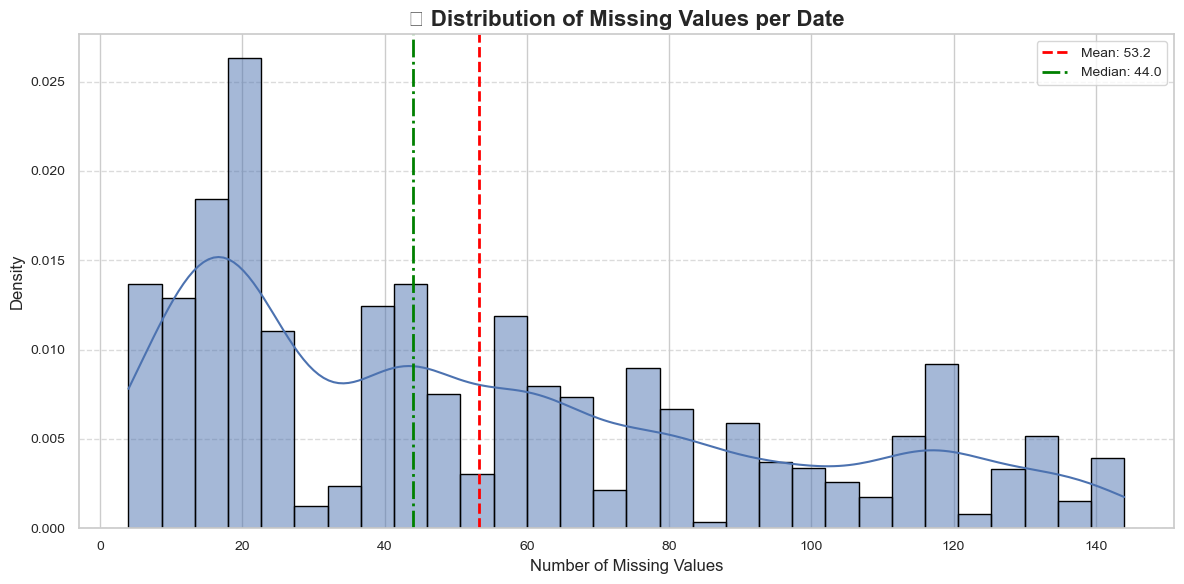

In [16]:

# Compute mean and median
mean_val = nan_per_date.mean()
median_val = nan_per_date.median()

# Seaborn style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))

# Color by density using KDE to get smoother gradient
sns.histplot(nan_per_date, bins=30, stat='density', kde=True,
             palette='viridis', edgecolor='black')

# Add vertical lines for mean and median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Median: {median_val:.1f}')

# Labels and title
plt.title("📊 Distribution of Missing Values per Date", fontsize=16, weight='bold')
plt.xlabel("Number of Missing Values", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Customize ticks and legend
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### DROPPING NANS

In [12]:
# REMOVE TICKERS WITH NAN VALUES
# Drop columns with any NaNs
stock_data_clean = stock_data.dropna(axis=1)

print(f"Original shape: {stock_data.shape}")
print(f"Cleaned shape: {stock_data_clean.shape}")


Original shape: (3770, 1007)
Cleaned shape: (3770, 863)


In [13]:
# CHECK
# Check for any remaining NaNs
nan_check = stock_data_clean.isna().sum().sum()
print(f"Total NaN values after cleanup: {nan_check}")


Total NaN values after cleanup: 0


In [14]:
# Columns that were dropped
dropped_columns = stock_data.columns.difference(stock_data_clean.columns)
print(f"Dropped columns ({len(dropped_columns)}):")
print(dropped_columns.tolist())

Dropped columns (144):
['ABBV.close', 'ABBV.open', 'ABNB.close', 'ABNB.open', 'ALLE.close', 'ALLE.open', 'AMCR.close', 'AMCR.open', 'ANET.close', 'ANET.open', 'APO.close', 'APO.open', 'APTV.close', 'APTV.open', 'CARR.close', 'CARR.open', 'CBOE.close', 'CBOE.open', 'CDW.close', 'CDW.open', 'CEG.close', 'CEG.open', 'CFG.close', 'CFG.open', 'CPAY.close', 'CPAY.open', 'CRWD.close', 'CRWD.open', 'CTAS.close', 'CTAS.open', 'CTVA.close', 'CTVA.open', 'CZR.close', 'CZR.open', 'DAY.close', 'DAY.open', 'DELL.close', 'DELL.open', 'DOW.close', 'DOW.open', 'ENPH.close', 'ENPH.open', 'EPAM.close', 'EPAM.open', 'ETR.close', 'ETR.open', 'FANG.close', 'FANG.open', 'FOX.close', 'FOX.open', 'FOXA.close', 'FOXA.open', 'FTV.close', 'FTV.open', 'GDDY.close', 'GDDY.open', 'GEHC.close', 'GEHC.open', 'GEV.close', 'GEV.open', 'GM.close', 'GM.open', 'HCA.close', 'HCA.open', 'HII.close', 'HII.open', 'HLT.close', 'HLT.open', 'HPE.close', 'HPE.open', 'HWM.close', 'HWM.open', 'INVH.close', 'INVH.open', 'IQV.close', 

In [15]:
# Min and max dates in the cleaned DataFrame
min_date = stock_data_clean['Date'].min()
max_date = stock_data_clean['Date'].max()

print(f"Min Date: {min_date}")
print(f"Max Date: {max_date}")

Min Date: 2010-03-22 00:00:00
Max Date: 2025-03-14 00:00:00


### SOME DIST PLOTS

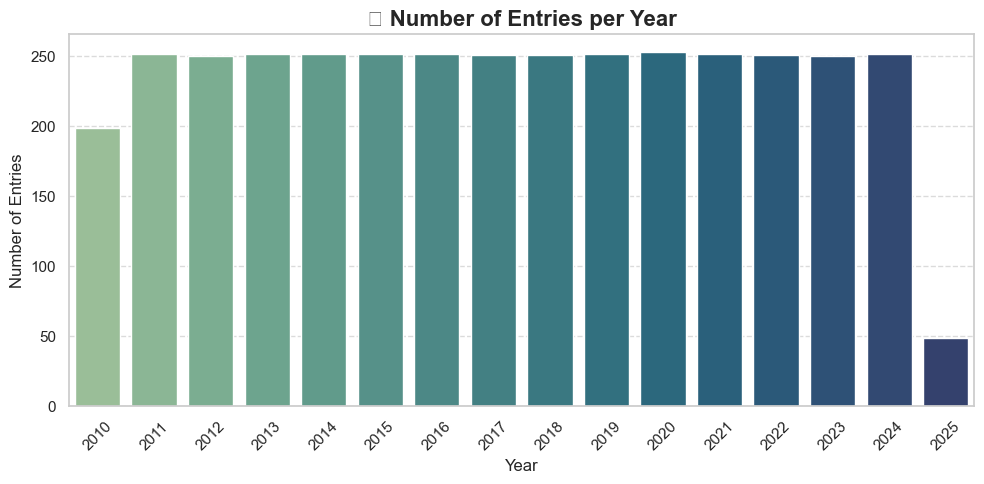

In [24]:
# Extract year from Date
stock_data_clean['Year'] = stock_data_clean['Date'].dt.year

# Plot distribution of rows by year
plt.figure(figsize=(10, 5))
sns.countplot(data=stock_data_clean, x='Year', palette='crest')

plt.title("📅 Number of Entries per Year", fontsize=16, weight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Entries", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


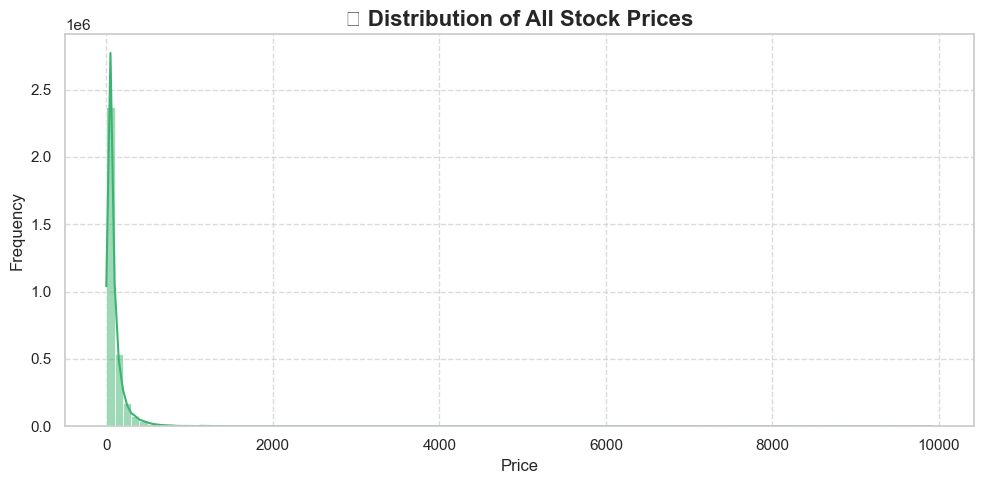

In [26]:
# Select only numeric price columns
price_data = stock_data_clean.drop(columns=['Date', 'Year'])

# Flatten all price values into a single series
all_prices = price_data.values.flatten()

# Plot histogram
plt.figure(figsize=(10, 5))
sns.histplot(all_prices, bins=100, kde=True, color='mediumseagreen')

plt.title("💰 Distribution of All Stock Prices", fontsize=16, weight='bold')
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


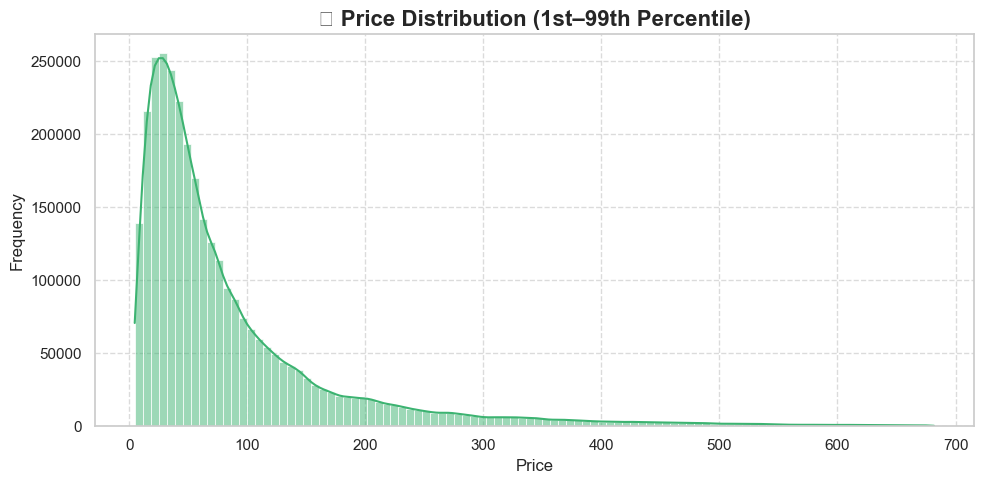

In [28]:
# Drop extreme outliers using percentiles
low, high = np.percentile(all_prices, [1, 99])
filtered_prices = all_prices[(all_prices >= low) & (all_prices <= high)]

# Plot trimmed price distribution
plt.figure(figsize=(10, 5))
sns.histplot(filtered_prices, bins=100, kde=True, color='mediumseagreen')

plt.title("💰 Price Distribution (1st–99th Percentile)", fontsize=16, weight='bold')
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


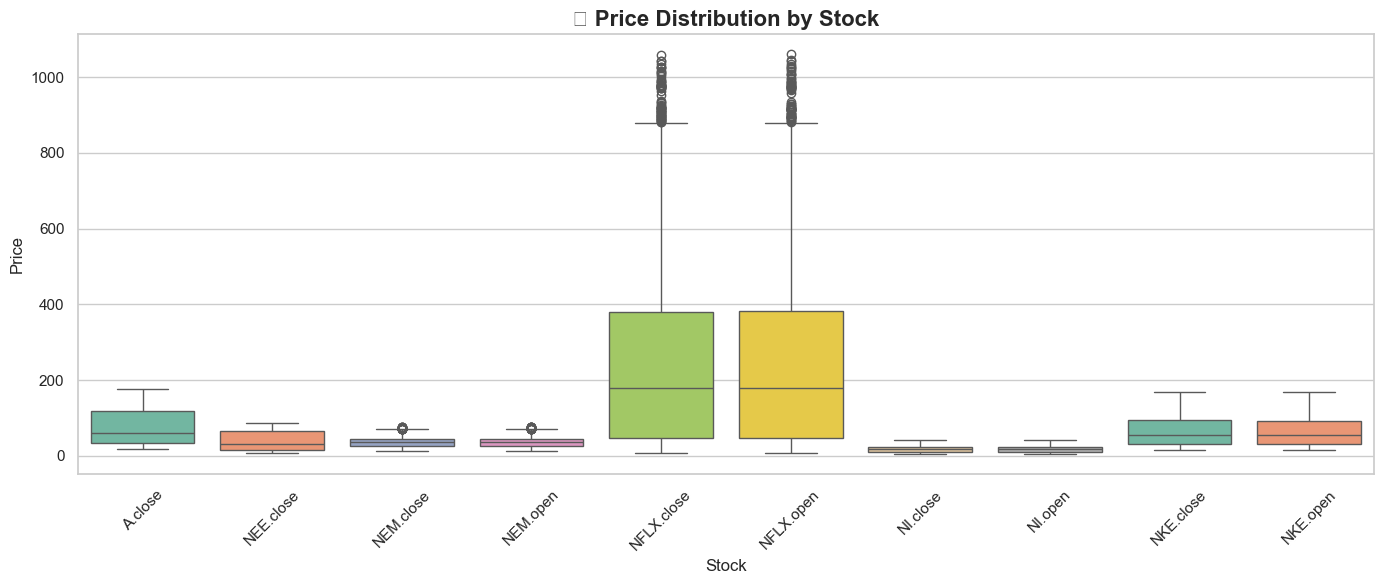

In [27]:
#Boxplot of Prices (Grouped by Stock)

# Melt to long format for seaborn
melted = price_data.melt(var_name='Stock', value_name='Price')
# fileter top 10
top_stocks = melted['Stock'].value_counts().head(10).index
filtered = melted[melted['Stock'].isin(top_stocks)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=filtered, x='Stock', y='Price', palette='Set2')

plt.title(" Price Distribution by Stock", fontsize=16, weight='bold')
plt.xlabel("Stock", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [29]:
print(stock_data_clean.head())

        Date    A.close     A.open  AAPL.close  AAPL.open  ABT.close  \
0 2010-03-22  21.563597  21.269431    6.763536   6.634736  18.598389   
1 2010-03-23  21.813002  21.601970    6.872173   6.790318  18.760651   
2 2010-03-24  21.678694  21.729854    6.902567   6.850505  18.598389   
3 2010-03-25  22.094370  21.806600    6.820715   6.949215  18.477552   
4 2010-03-26  21.940891  22.158317    6.948610   6.889927  18.263506   

    ABT.open  ACGL.close  ACGL.open  ACN.close  ...   XEL.open  XOM.close  \
0  18.436123    7.941060   7.869214  32.215126  ...  12.718738  37.942776   
1  18.681245    7.951624   7.934720  32.192348  ...  12.691810  37.931442   
2  18.729582    7.972756   7.955851  31.729200  ...  12.715747  37.676472   
3  18.739940    7.951624   7.983322  31.524208  ...  12.691810  37.563168   
4  18.539703    7.954795   7.978039  32.192348  ...  12.637952  37.699154   

    XOM.open  YUM.close   YUM.open  ZBH.close   ZBH.open  ZBRA.close  \
0  37.670823  20.547918  20.3540

In [16]:
# Get all column names (excluding 'Date')
price_cols = stock_data_clean.columns.drop('Date')

# Each stock has both '.open' and '.close' — extract unique tickers
tickers = set(col.split('.')[0] for col in price_cols)

print(f"✅ Number of stocks remaining: {len(tickers)}")


✅ Number of stocks remaining: 431


In [17]:
#stock_data_clean = stock_data_clean.drop(columns=['Year'])
# 1. Get original list of price columns (before dropping NaNs)
original_price_cols = stock_data.columns.drop('Date')
#original_tickers = set(col.split('.')[0] for col in stock_data.columns if col != 'Date')

# 2. Get cleaned list of price columns (after dropping NaNs)
cleaned_price_cols = stock_data_clean.columns.drop('Date')
#cleaned_tickers = set(col.split('.')[0] for col in stock_data_clean.columns if col != 'Date')

#  Use these instead of all columns
original_tickers = set(col.split('.')[0] for col in original_price_cols)
cleaned_tickers = set(col.split('.')[0] for col in cleaned_price_cols)

# 3. Calculate difference
dropped_tickers = original_tickers - cleaned_tickers

# 4. Print summary
print(f"📦 Original number of stocks: {len(original_tickers)}")
print(f"✅ Stocks remaining after cleaning: {len(cleaned_tickers)}")
print(f"❌ Stocks dropped due to missing data: {len(dropped_tickers)}")


📦 Original number of stocks: 503
✅ Stocks remaining after cleaning: 431
❌ Stocks dropped due to missing data: 72


### ETF Cleaning

In [19]:
# Load CSV file
etf_data = pd.read_csv('etf_data.csv')

# Show the first few rows
print(etf_data.head())

# Show all column names
print(etf_data.columns.tolist())

         Date  XLB.close   XLB.open  XLC.close  XLC.open  XLE.close  \
0  22/03/2010  24.492754  23.941539        NaN       NaN  35.019302   
1  23/03/2010  24.811880  24.514515        NaN       NaN  35.154156   
2  24/03/2010  24.739342  24.652309        NaN       NaN  34.951874   
3  25/03/2010  24.246166  24.964194        NaN       NaN  34.363422   
4  26/03/2010  24.427483  24.354956        NaN       NaN  34.375675   

    XLE.open  XLF.close  XLF.open  XLI.close  ...  XLP.close   XLP.open  \
0  34.669906   9.805779  9.656547  23.287149  ...  18.729361  18.561595   
1  35.098988   9.886611  9.830649  23.550919  ...  18.876997  18.722653   
2  34.921225   9.892826  9.824427  23.385124  ...  18.742781  18.870283   
3  35.203199   9.936354  9.961226  23.370050  ...  18.715939  18.809888   
4  34.479880   9.948791  9.979880  23.430346  ...  18.729361  18.756204   

   XLRE.close  XLRE.open  XLU.close   XLU.open  XLV.close   XLV.open  \
0         NaN        NaN  17.782763  17.830566  25

In [20]:
# Convert Date to datetime
etf_data['Date'] = pd.to_datetime(etf_data['Date'])

In [21]:
# Step 1: Count missing values
print(etf_data.isna().sum())

# Step 2: Drop columns with any NaNs
etf_data_clean = etf_data.dropna(axis=1)

# Step 3: Confirm no missing values
print(f"Remaining columns: {etf_data_clean.shape[1]}")
print(f"Remaining ETFs: {len(set(col.split('.')[0] for col in etf_data_clean.columns if col != 'Date'))}")
print(f"Total NaNs: {etf_data_clean.isna().sum().sum()}")


Date             0
XLB.close        0
XLB.open         0
XLC.close     2076
XLC.open      2076
XLE.close        0
XLE.open         0
XLF.close        0
XLF.open         0
XLI.close        0
XLI.open         0
XLK.close        0
XLK.open         0
XLP.close        0
XLP.open         0
XLRE.close    1398
XLRE.open     1398
XLU.close        0
XLU.open         0
XLV.close        0
XLV.open         0
XLY.close        0
XLY.open         0
dtype: int64
Remaining columns: 19
Remaining ETFs: 9
Total NaNs: 0


In [24]:
print(etf_data_clean.head())

        Date  XLB.close   XLB.open  XLE.close   XLE.open  XLF.close  XLF.open  \
0 2010-03-22  24.492754  23.941539  35.019302  34.669906   9.805779  9.656547   
1 2010-03-23  24.811880  24.514515  35.154156  35.098988   9.886611  9.830649   
2 2010-03-24  24.739342  24.652309  34.951874  34.921225   9.892826  9.824427   
3 2010-03-25  24.246166  24.964194  34.363422  35.203199   9.936354  9.961226   
4 2010-03-26  24.427483  24.354956  34.375675  34.479880   9.948791  9.979880   

   XLI.close   XLI.open  XLK.close   XLK.open  XLP.close   XLP.open  \
0  23.287149  23.045988  18.705494  18.477379  18.729361  18.561595   
1  23.550919  23.347438  18.884729  18.770672  18.876997  18.722653   
2  23.385124  23.468022  18.795113  18.795113  18.742781  18.870283   
3  23.370050  23.603675  18.827703  18.917319  18.715939  18.809888   
4  23.430346  23.445418  18.738091  18.876590  18.729361  18.756204   

   XLU.close   XLU.open  XLV.close   XLV.open  XLY.close   XLY.open  
0  17.782763  17

In [22]:
# 1. Extract original ETF tickers (before dropping NaNs)
original_etf_cols = etf_data.columns.drop('Date')
original_etfs = set(col.split('.')[0] for col in original_etf_cols)

# 2. Extract cleaned ETF tickers (after dropping NaNs)
cleaned_etf_cols = etf_data_clean.columns.drop('Date')
cleaned_etfs = set(col.split('.')[0] for col in cleaned_etf_cols)

# 3. Find dropped ETFs
dropped_etfs = original_etfs - cleaned_etfs

# 4. Print results
print(f"📦 Original number of ETFs: {len(original_etfs)}")
print(f"✅ ETFs remaining after cleaning: {len(cleaned_etfs)}")
print(f"❌ ETFs dropped due to missing data: {len(dropped_etfs)}")
print("\nDropped ETFs:", sorted(dropped_etfs))


📦 Original number of ETFs: 11
✅ ETFs remaining after cleaning: 9
❌ ETFs dropped due to missing data: 2

Dropped ETFs: ['XLC', 'XLRE']


In [23]:
# Min and max dates in the cleaned DataFrame
min_date_etf = etf_data_clean['Date'].min()
max_date_etf = etf_data_clean['Date'].max()

print(f"Min Date: {min_date_etf}")
print(f"Max Date: {max_date_etf}")

Min Date: 2010-03-22 00:00:00
Max Date: 2025-03-14 00:00:00


In [28]:
mapping_df = pd.read_csv('Fin-GAN-main/datasets/stocks-etfs-list.csv')

print(mapping_df.head())

  ticker_x             Security                  Sector SectorTicker  \
0      MMM                   3M             Industrials          XLI   
1      AOS          A. O. Smith             Industrials          XLI   
2      ABT  Abbott Laboratories             Health Care          XLV   
3     ABBV               AbbVie             Health Care          XLV   
4      ACN            Accenture  Information Technology          XLK   

  date_start_x   len_x ticker_y date_start_y   len_y  
0  2010 -03-22  5598.0      XLI  2010 -03-22  5598.0  
1  2010 -03-22  5598.0      XLI  2010 -03-22  5598.0  
2  2010 -03-22  5598.0      XLV  2010 -03-22  5598.0  
3  2010 -03-22  5598.0      XLV  2010 -03-22  5598.0  
4  2010 -03-22  5598.0      XLK  2010 -03-22  5598.0  


In [30]:
# Drop the stocks related to the dropped etfs
dropped_etfs = ['XLC', 'XLRE']

#Get list of stock tickers that map to those dropped ETFs
stocks_to_remove = mapping_df[mapping_df['ticker_y'].isin(dropped_etfs)]['ticker_x'].unique()


In [31]:
# Prepare columns to drop from stock_data_clean
columns_to_drop = []
for ticker in stocks_to_remove:
    columns_to_drop.extend([f"{ticker}.open", f"{ticker}.close"])

# Drop them safely (only if they exist)
stock_data_clean = stock_data_clean.drop(columns=[col for col in columns_to_drop if col in stock_data_clean.columns])

# Print summary
print(f"❌ Dropped {len(stocks_to_remove)} stocks associated with removed ETFs: {dropped_etfs}")
print(f"📉 Columns removed: {len(columns_to_drop)}")

❌ Dropped 53 stocks associated with removed ETFs: ['XLC', 'XLRE']
📉 Columns removed: 106


In [32]:
# Get all remaining columns except 'Date'
price_cols = stock_data_clean.columns.drop('Date')

# Extract unique tickers from column names
remaining_tickers = set(col.split('.')[0] for col in price_cols)

# Count them
print(f" Number of stocks remaining after ETF filter: {len(remaining_tickers)}")


✅ Number of stocks remaining after ETF filter: 385


In [37]:
print(remaining_tickers)

{'RMD', 'GPN', 'STZ', 'HUM', 'AME', 'MCHP', 'AKAM', 'NKE', 'ZBH', 'PRU', 'UNH', 'SMCI', 'TXN', 'WFC', 'BAX', 'PHM', 'SNA', 'VTRS', 'TYL', 'LMT', 'C', 'COO', 'ICE', 'ACGL', 'MHK', 'CME', 'USB', 'EVRG', 'CL', 'REGN', 'GE', 'RJF', 'ATO', 'UHS', 'AZO', 'CAH', 'ADBE', 'AMGN', 'UNP', 'GLW', 'AMD', 'AON', 'TPR', 'L', 'STLD', 'MKC', 'FE', 'LVS', 'HOLX', 'AAPL', 'WBA', 'RF', 'HPQ', 'SWK', 'FTNT', 'BAC', 'IP', 'TSN', 'WDC', 'FCX', 'CCL', 'QCOM', 'PNR', 'AWK', 'PEG', 'JBL', 'ORLY', 'EW', 'NRG', 'LII', 'BIIB', 'LEN', 'DECK', 'CMI', 'DPZ', 'LLY', 'PODD', 'STE', 'ADI', 'BLK', 'ABT', 'ACN', 'MMM', 'TRV', 'KLAC', 'SRE', 'PFG', 'BEN', 'EIX', 'NDSN', 'EXPD', 'NDAQ', 'MNST', 'DAL', 'J', 'CNP', 'BRO', 'EL', 'SLB', 'K', 'CAG', 'GWW', 'FDX', 'ODFL', 'MGM', 'CE', 'NTRS', 'NEM', 'HAS', 'HIG', 'CVX', 'PAYX', 'WST', 'EXC', 'PGR', 'ECL', 'CSX', 'CMS', 'SWKS', 'TAP', 'JNJ', 'DTE', 'DLTR', 'CHD', 'MSFT', 'ORCL', 'APH', 'AVGO', 'AVY', 'STT', 'BF-B', 'MRK', 'ON', 'LRCX', 'GEN', 'HRL', 'AFL', 'BKR', 'AXON', 'EMN', 'I

In [33]:
# Save

# Create the new folder if it doesn't exist
# os.makedirs('data_clean', exist_ok=True)

#Save the cleaned Stock data
stock_data_clean.to_csv('data_clean/stock_data.csv', index=False)

# Save cleaned ETF data
os.makedirs('data_clean', exist_ok=True)
etf_data_clean.to_csv('data_clean/etf_data.csv', index=False)

### Creating the single files

In [39]:
# ALIGNED FILES TO AVOID MISMATCH WITH NAN


# === CONFIG ===
stock_data_file = 'data_clean/stock_data.csv'
etf_data_file = 'data_clean/etf_data.csv'
mapping_file = 'data_clean/stocks-etfs-list.csv'
# mapping_file = 'Fin-GAN-main/datasets/stocks-etfs-list.csv' # it's the same one, I put a copy in the other location  for consistency
output_path = 'Fin-GAN-main/datasets'

# === SETUP ===
os.makedirs(output_path, exist_ok=True)

# load data

stock_data = pd.read_csv(stock_data_file)
etf_data = pd.read_csv(etf_data_file)
mapping_df = pd.read_csv(mapping_file)

stock_data['Date'] = pd.to_datetime(stock_data['Date'])
etf_data['Date'] = pd.to_datetime(etf_data['Date'])

stock_data.set_index('Date', inplace=False)
etf_data.set_index('Date', inplace=False)

# === MAIN LOOP: Process each stock and its ETF ===
for _, row in mapping_df.iterrows():
    stock = row['ticker_x']
    etf = row['ticker_y']

    stock_close = f"{stock}.close"
    stock_open = f"{stock}.open"
    etf_close = f"{etf}.close"
    etf_open = f"{etf}.open"

    # Check required columns
    if all(col in stock_data.columns for col in [stock_close, stock_open]) and \
       all(col in etf_data.columns for col in [etf_close, etf_open]):

        # Extract data
        s_df = stock_data[['Date', stock_close, stock_open]].copy()
        s_df.columns = ['date', 'AdjClose_stock', 'AdjOpen_stock']

        e_df = etf_data[['Date', etf_close, etf_open]].copy()
        e_df.columns = ['date', 'AdjClose_etf', 'AdjOpen_etf']

        # Merge and align
        merged = pd.merge(s_df, e_df, on='date', how='inner')
        merged.dropna(inplace=True)

        # === Save aligned stock ===
        s_out = merged[['date', 'AdjClose_stock', 'AdjOpen_stock']].rename(
            columns={'AdjClose_stock': 'AdjClose', 'AdjOpen_stock': 'AdjOpen'}
        )
        s_out.to_csv(os.path.join(output_path, f"{stock}.csv"), index=False)

        # === Save aligned ETF ===
        e_out = merged[['date', 'AdjClose_etf', 'AdjOpen_etf']].rename(
            columns={'AdjClose_etf': 'AdjClose', 'AdjOpen_etf': 'AdjOpen'}
        )
        e_out.to_csv(os.path.join(output_path, f"{etf}.csv"), index=False)

        print(f"✅ Saved aligned: {stock}.csv and {etf}.csv")

    else:
        print(f"⚠️ Skipped {stock} or {etf} — missing columns")

print("🎯 All files are clean, aligned, and FinGAN-ready!")

✅ Saved aligned: MMM.csv and XLI.csv
✅ Saved aligned: AOS.csv and XLI.csv
✅ Saved aligned: ABT.csv and XLV.csv
⚠️ Skipped ABBV or XLV — missing columns
✅ Saved aligned: ACN.csv and XLK.csv
✅ Saved aligned: ADBE.csv and XLK.csv
✅ Saved aligned: AMD.csv and XLK.csv
✅ Saved aligned: AES.csv and XLU.csv
✅ Saved aligned: AFL.csv and XLF.csv
✅ Saved aligned: A.csv and XLV.csv
✅ Saved aligned: APD.csv and XLB.csv
⚠️ Skipped ABNB or XLY — missing columns
✅ Saved aligned: AKAM.csv and XLK.csv
✅ Saved aligned: ALB.csv and XLB.csv
⚠️ Skipped ARE or XLRE — missing columns
✅ Saved aligned: ALGN.csv and XLV.csv
⚠️ Skipped ALLE or XLI — missing columns
✅ Saved aligned: LNT.csv and XLU.csv
✅ Saved aligned: ALL.csv and XLF.csv
⚠️ Skipped GOOGL or XLC — missing columns
⚠️ Skipped GOOG or XLC — missing columns
✅ Saved aligned: MO.csv and XLP.csv
✅ Saved aligned: AMZN.csv and XLY.csv
⚠️ Skipped AMCR or XLB — missing columns
✅ Saved aligned: AEE.csv and XLU.csv
✅ Saved aligned: AEP.csv and XLU.csv
✅ Saved 

In [40]:
# Count how many CSVs were written to the output folder to check correctness 
output_files = [f for f in os.listdir(output_path) if f.endswith('.csv')]
print(f"\n📁 Total aligned output files saved: {len(output_files)}")

# + 1 that is the mapping file


📁 Total aligned output files saved: 395


In [41]:
etfs_saved = set(row['SectorTicker'] for _, row in mapping_df.iterrows()
                 if f"{row['SectorTicker']}.csv" in os.listdir(output_path))
print(f"ETF files actually saved: {len(etfs_saved)} → {sorted(etfs_saved)}")


🎯 ETF files actually saved: 9 → ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']


## Sectors selection

In [42]:
# Counting of the stocks per sector to determine which ones to use


# === File paths ===
stock_data_path = 'data_clean/stock_data.csv'
etf_mapping_path = 'data_clean/stocks-etfs-list.csv'

# === Load data ===
stock_data = pd.read_csv(stock_data_path)
etf_mapping = pd.read_csv(etf_mapping_path)

# === Extract tickers from stock_data columns ===
# Stock columns are in format: TICKER.open, TICKER.close, etc.
# We'll split on '.' and get unique tickers
all_columns = stock_data.columns
tickers_in_data = set(col.split('.')[0] for col in all_columns if '.' in col)

# === Filter ETF mapping for only tickers present in stock_data ===
mapped_tickers = etf_mapping[etf_mapping['ticker_x'].isin(tickers_in_data)]

# === Count how many per sector ===
sector_counts = mapped_tickers["Sector"].value_counts()
print("📊 Ticker counts by sector:\n")
print(sector_counts)

# Optional: save to CSV
sector_counts.to_csv("sector_counts.csv")


📊 Ticker counts by sector:

Sector
Financials                66
Industrials               64
Information Technology    55
Health Care               54
Consumer Discretionary    43
Consumer Staples          35
Utilities                 28
Materials                 23
Energy                    17
Name: count, dtype: int64


In [44]:
# Analysis to decide which sectors to include

# Load data
df = stock_data
etf_mapping = pd.read_csv("data_clean/stocks-etfs-list.csv")

# Extract tickers
tickers = set(col.split('.')[0] for col in df.columns if '.' in col)

# Compute daily returns for each ticker
returns = {}
for ticker in tickers:
    if f"{ticker}.close" in df.columns:
        close_prices = df[f"{ticker}.close"]
        returns[ticker] = close_prices.pct_change().dropna()

# Average volatility per ticker
vol_df = pd.DataFrame({k: v.std() for k, v in returns.items()}, index=["volatility"]).T
vol_df = vol_df.reset_index().rename(columns={"index": "ticker_x"})

# Map to sectors
merged = pd.merge(vol_df, etf_mapping[["ticker_x", "Sector"]], on="ticker_x")
sector_vol = merged.groupby("Sector")["volatility"].mean().sort_values(ascending=False)

print("📊 Average volatility by sector:")
print(sector_vol)


📊 Average volatility by sector:
Sector
Energy                    0.024260
Information Technology    0.021456
Consumer Discretionary    0.021005
Materials                 0.019776
Health Care               0.018237
Industrials               0.018015
Financials                0.017714
Consumer Staples          0.014713
Utilities                 0.014498
Name: volatility, dtype: float64


📊 Volatility and Ticker Count by Sector:
                        avg_volatility  ticker_count
Sector                                              
Energy                        0.024260            17
Information Technology        0.021456            55
Consumer Discretionary        0.021005            43
Materials                     0.019776            23
Health Care                   0.018237            54
Industrials                   0.018015            64
Financials                    0.017714            66
Consumer Staples              0.014713            35
Utilities                     0.014498            28


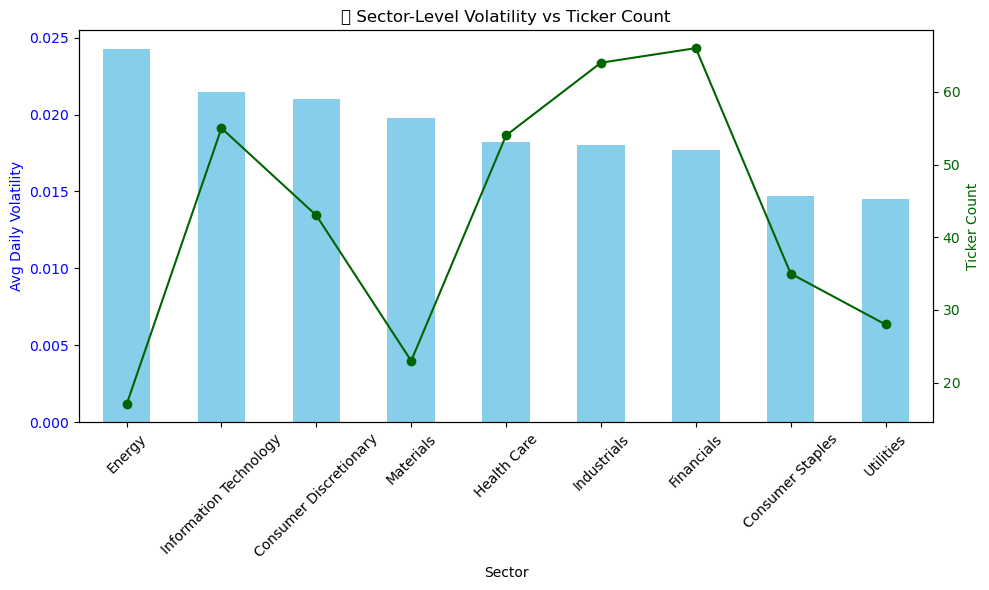

In [45]:

# === Aggregations ===
# Average volatility per sector
sector_vol = merged.groupby("Sector")["volatility"].mean()

# Ticker count per sector
sector_counts = merged["Sector"].value_counts()

# === Combine into single DataFrame ===
summary_df = pd.DataFrame({
    "avg_volatility": sector_vol,
    "ticker_count": sector_counts
}).sort_values("avg_volatility", ascending=False)

print("📊 Volatility and Ticker Count by Sector:")
print(summary_df)

# === Plot: Combined chart ===
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for average volatility
summary_df["avg_volatility"].plot(kind="bar", color="skyblue", ax=ax1)
ax1.set_ylabel("Avg Daily Volatility", color="blue")
ax1.set_xlabel("Sector")
ax1.tick_params(axis='y', labelcolor="blue")
plt.xticks(rotation=45)

# Add secondary axis for ticker count
ax2 = ax1.twinx()
summary_df["ticker_count"].plot(kind="line", marker="o", color="darkgreen", ax=ax2)
ax2.set_ylabel("Ticker Count", color="darkgreen")
ax2.tick_params(axis='y', labelcolor="darkgreen")

plt.title("📈 Sector-Level Volatility vs Ticker Count")
plt.tight_layout()
plt.show()


In [50]:
from IPython.display import Markdown

markdown_table = """
###  Sector Relevance (2010–2025)

| Top Sector  (score 1)    | Relevance (2010–2025)                                   |
|--------------------------|----------------------------------------------------------|
| Information Technology   | Explosive growth *(FANG, AI, semis)*                 |
| Financials               | Post-GFC recovery, fintech                          |
| Energy                   | Volatility due to oil crises, green energy shift     |
| Health Care              | COVID, biotech boom                                  |
| Consumer Discretionary   | Pandemic demand shifts, e-commerce                  |
"""

display(Markdown(markdown_table))



###  Sector Relevance (2010–2025)

| Top Sector  (score 1)    | Relevance (2010–2025)                                   |
|--------------------------|----------------------------------------------------------|
| Information Technology   | Explosive growth *(FANG, AI, semis)*                 |
| Financials               | Post-GFC recovery, fintech                          |
| Energy                   | Volatility due to oil crises, green energy shift     |
| Health Care              | COVID, biotech boom                                  |
| Consumer Discretionary   | Pandemic demand shifts, e-commerce                  |


In [46]:
# Considering also economic relevance of the sector in time frame (2010 - 2025)


# === Load sector-level data ===
# from previous analysis
sector_volatility = {
    'Energy': 0.024260,
    'Information Technology': 0.021456,
    'Consumer Discretionary': 0.021005,
    'Materials': 0.019776,
    'Health Care': 0.018237,
    'Industrials': 0.018015,
    'Financials': 0.017714,
    'Consumer Staples': 0.014713,
    'Utilities': 0.014498
}

sector_ticker_counts = {
    'Financials': 66,
    'Industrials': 64,
    'Information Technology': 55,
    'Health Care': 54,
    'Consumer Discretionary': 43,
    'Consumer Staples': 35,
    'Utilities': 28,
    'Materials': 23,
    'Energy': 17
}

# === Assign manual relevance (1 = relevant, 0 = deprioritized) ===
relevance_flag = {
    'Information Technology': 1,
    'Financials': 1,
    'Energy': 1,
    'Health Care': 1,
    'Consumer Discretionary': 1,
    'Industrials': 0,
    'Consumer Staples': 0,
    'Utilities': 0,
    'Materials': 0
}

# === Build DataFrame ===
df = pd.DataFrame({
    "avg_volatility": sector_volatility,
    "ticker_count": sector_ticker_counts,
    "relevance": relevance_flag
})

# === Compute Score ===
df["score"] = df["avg_volatility"] * df["relevance"] * np.log(df["ticker_count"])

# === Sort and display ===
df_sorted = df.sort_values("score", ascending=False)

print("📊 Sector ranking by composite score:")
print(df_sorted[["avg_volatility", "ticker_count", "relevance", "score"]])


📊 Sector ranking by composite score:
                        avg_volatility  ticker_count  relevance     score
Information Technology        0.021456            55          1  0.085981
Consumer Discretionary        0.021005            43          1  0.079004
Financials                    0.017714            66          1  0.074216
Health Care                   0.018237            54          1  0.072747
Energy                        0.024260            17          1  0.068734
Materials                     0.019776            23          0  0.000000
Industrials                   0.018015            64          0  0.000000
Consumer Staples              0.014713            35          0  0.000000
Utilities                     0.014498            28          0  0.000000
